In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yrpoOLp4rdpJgqSZFNGo")
project = rf.workspace("franciscos-workspace-db7in").project("deteccion-skins")
version = project.version(8)
dataset = version.download("yolo26")
                


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteccion-Skins-8 in yolo26:: 100%|██████████| 11647/11647 [00:12<00:00, 924.91it/s] 


In [2]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

%matplotlib inline

# **Entrenar Modelo**

In [32]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: NVIDIA GeForce RTX 3060 Laptop GPU


In [33]:
# Cargar un modelo YOLO26n preentrenado
model = YOLO("yolo26n.pt")

In [34]:
model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

In [ ]:
# Cargar tu modelo base
model = YOLO("yolo26n.pt")

train_results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=80,
    imgsz=640,
    batch=8,
    patience=10,
    workers=0,   
    device=0,
)

New https://pypi.org/project/ultralytics/8.4.93 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.92  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\famat\ElectivoVisionComputador\Proyecto_Trabajo_Lol\Deteccion-Skins-7/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

## Evaluar métricas

In [36]:
# Cargar el mejor modelo
model = YOLO("runs/detect/train/weights/best.pt")

# Evaluar el modelo
metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.92  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO26n summary (fused): 122 layers, 2,380,686 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 191.266.8 MB/s, size: 16.1 KB)
val: Scanning C:\Users\famat\ElectivoVisionComputador\Proyecto_Trabajo_Lol\Deteccion-Skins-7\valid\labels.cache... 320 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 320/320 95.9Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 318, len(boxes) = 335. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.0it/s 9.8s0.5s
                   all        320        335      0.746      0.842      0.879      0.854
                Aatrox         10         10     

## Visualizar algunas validaciones


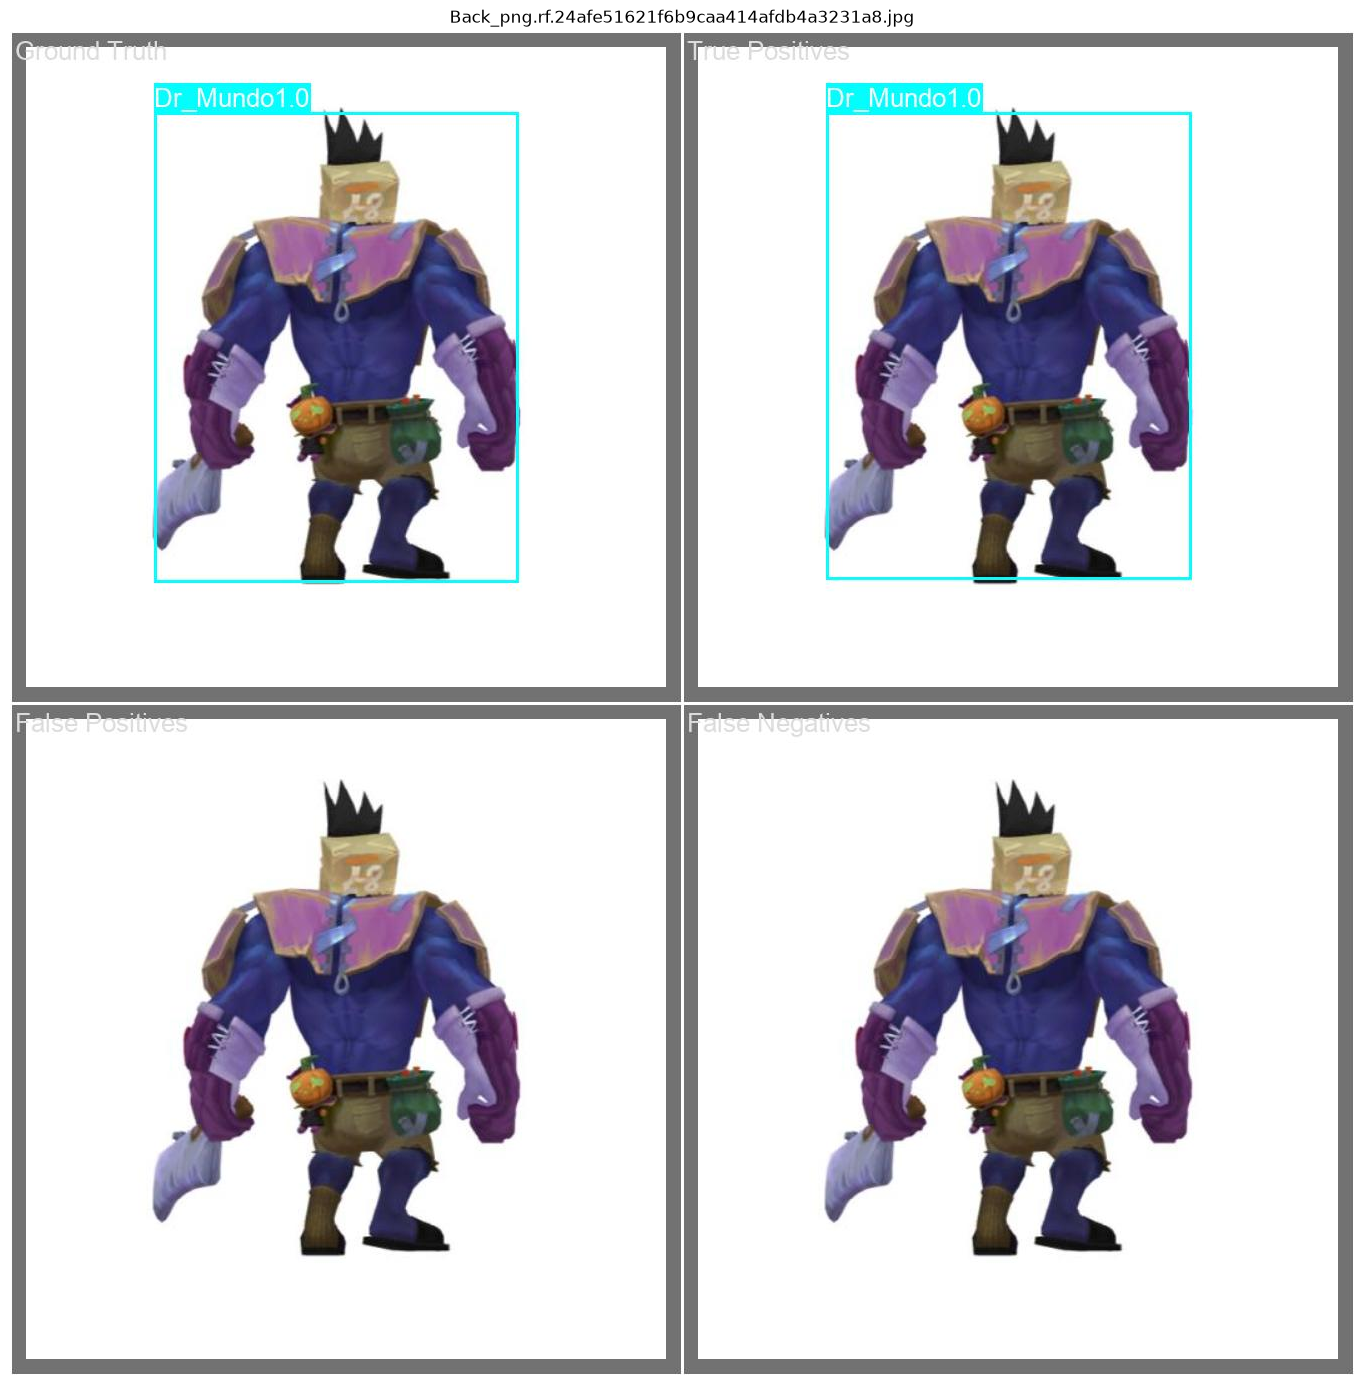

In [45]:
# Ruta de la imagen específica que quieres mostrar
img_path = 'runs/detect/val/visualizations/Back_png.rf.24afe51621f6b9caa414afdb4a3231a8.jpg'

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

## Evaluación gráfico F1-Score/Confidence


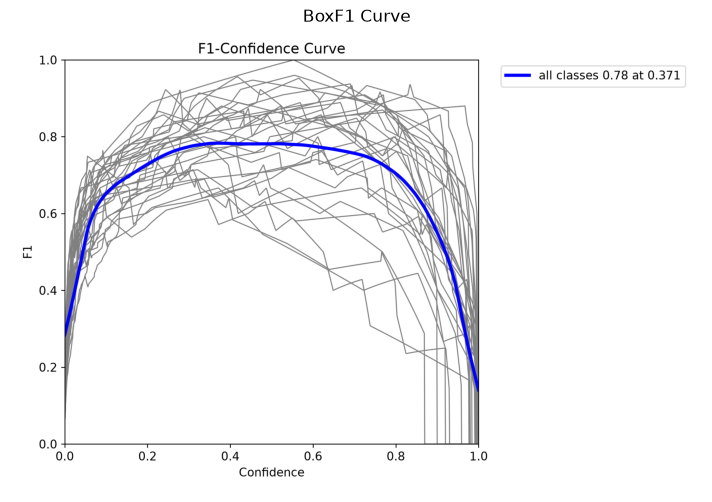

In [38]:
image_path = 'runs/detect/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Recall


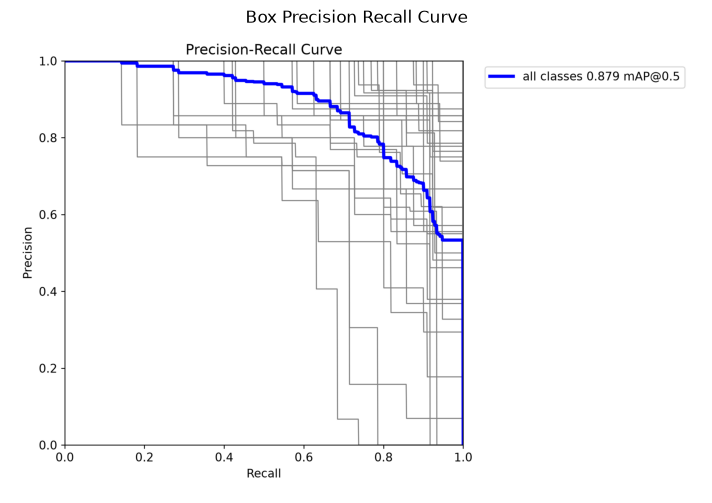

In [39]:
image_path = 'runs/detect/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Confidence

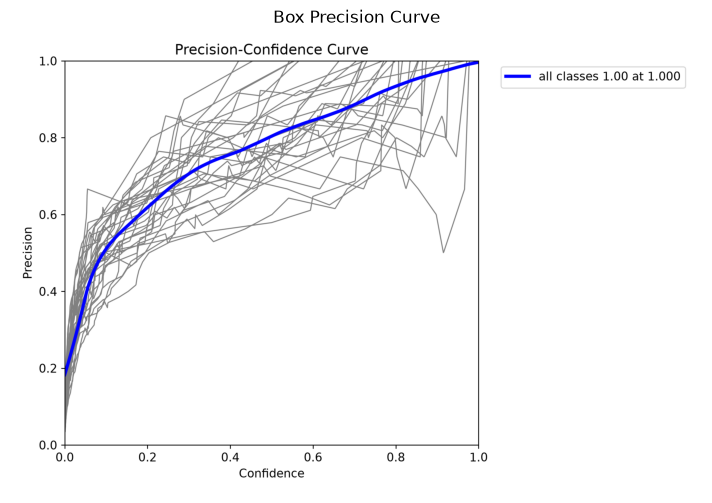

In [40]:
image_path = 'runs/detect/val/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Recall/Confidence


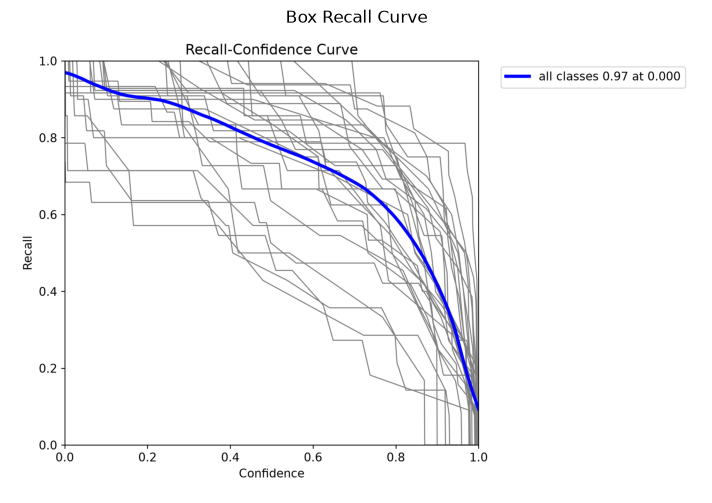

In [41]:
image_path = 'runs/detect/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión


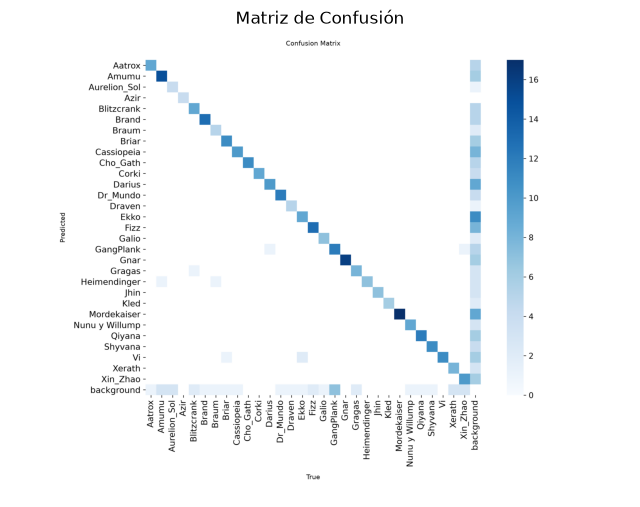

In [42]:
image_path = 'runs/detect/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión Normalizada

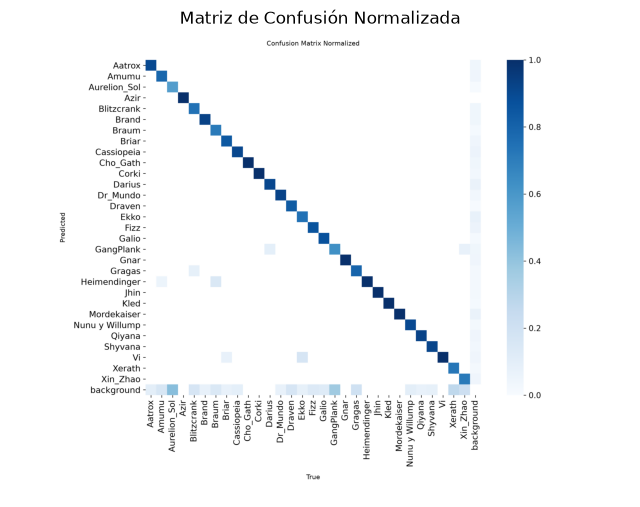

In [43]:
image_path = 'runs/detect/val/confusion_matrix_normalized.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión Normalizada')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Predicciones del modelo


image 1/1 c:\Users\famat\ElectivoVisionComputador\Proyecto_Trabajo_Lol\Deteccion-Skins-7\train\images\Captura-de-pantalla-2026-07-11-193834_png.rf.8b51b89cc13f384e97a4361b04cd2b1d.jpg: 640x640 2 Dr_Mundos, 12.3ms
Speed: 3.4ms preprocess, 12.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Resultados:  [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Aatrox', 1: 'Amumu', 2: 'Aurelion_Sol', 3: 'Azir', 4: 'Blitzcrank', 5: 'Brand', 6: 'Braum', 7: 'Briar', 8: 'Cassiopeia', 9: 'Cho_Gath', 10: 'Corki', 11: 'Darius', 12: 'Dr_Mundo', 13: 'Draven', 14: 'Ekko', 15: 'Fizz', 16: 'Galio', 17: 'GangPlank', 18: 'Gnar', 19: 'Gragas', 20: 'Heimendinger', 21: 'Jhin', 22: 'Kled', 23: 'Mordekaiser', 24: 'Nunu y Willump', 25: 'Qiyana', 26: 'Shyvana', 27: 'Vi', 28: 'Xerath', 29: 'Xin_Zhao'}
obb: None
orig_img: array([[[48, 74, 80],
        [49, 75, 81],
        [50, 76, 82],
        ...,
  

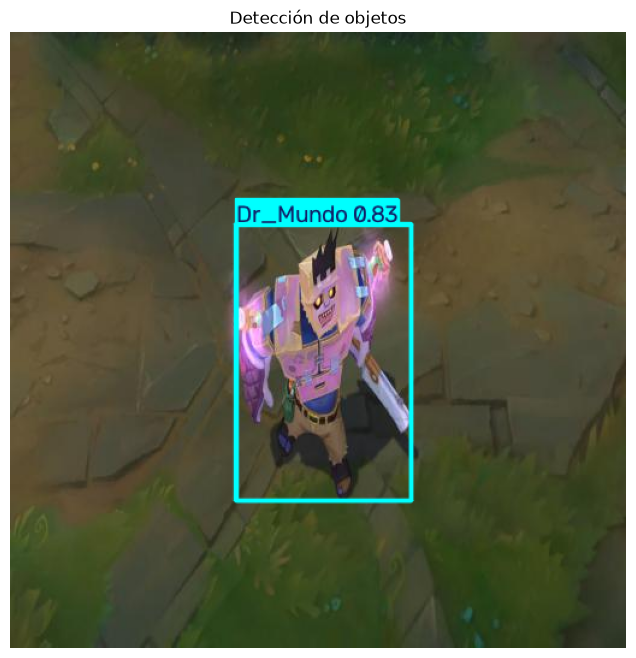

In [70]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('runs/detect/train/weights/best.pt')

# Ruta de la imagen
image_path = 'Deteccion-Skins-7/train/images/Captura-de-pantalla-2026-07-11-193834_png.rf.8b51b89cc13f384e97a4361b04cd2b1d.jpg'

#image_path = 'Captura de pantalla 2026-07-12 194613.png' 


# Realizar la detección
results = model(image_path)

print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de objetos')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)

In [ ]:
# Detección de objetos en video
model = YOLO('runs/detect/train/weights/best.pt')
video_path = 'video_prueba.mp4'  # <-- cambie esto por la ruta de tu video
output_path = 'resultado_video.mp4'

cap = cv.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: No se pudo abrir el video en la ruta: {video_path}")
else:
    # Obtener propiedades del video original
    fps = int(cap.get(cv.CAP_PROP_FPS))
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

    # Configurar el video de salida
    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    out = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)

        for r in results:
            boxes = r.boxes
            for box in boxes:
                print(f"Frame {frame_count} - Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")
            im_array = r.plot()
            out.write(im_array)

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Procesando frame {frame_count}/{total_frames}...")

    cap.release()
    out.release()